# 00 · Data & task

The trusted reference the rest of the analysis leans on: what data exists, whether
it is clean, and what the task is. Tables and descriptive plots — no statistics,
no fold. Read-only.

**Task.** 2-AFC auditory categorisation: on each trial a stimulus is drawn from a
distribution over the stimulus axis, and the mouse reports which side of the
category boundary it falls on. (Fill in the exact stimulus/apparatus.)

**Design.** The sensory statistics shift across phases — Uniform, then alternating
Hard-A ↔ Hard-B — and the animal must re-learn the boundary/priors at each switch.
Manipulations:
optogenetic PPC silencing (laser-on trials), masking (same light event, laser off —
the artifact control), and ALM-control (specificity). Genotypes: **het** (VGAT-ChR2,
silencing active) vs **wt** (light-only control).

Scope: the mouse behavioural cohorts — the early no-opto cohort (SS01–13) and the
opto cohort (SS14–23).

In [18]:
from shared_setup import *
apply_style()

experiment, info = load_data()
by_animal, groups = gather_genotypes(experiment)
opto_ids = groups.get('het', []) + groups.get('wt', [])

# one raw table across all animals (ungated — inventory/QC must see everything)
all_table = pd.concat([a.session_table.assign(animal=aid)
                       for aid, a in experiment.animals.items()], ignore_index=True)
all_table['genotype'] = all_table['animal'].map(by_animal).fillna('unknown')

n_sess = int(all_table['session_id'].nunique())
print(f"loaded ({info['mode']}): {experiment.n_animals} animals, {n_sess} sessions, "
      f"{int(all_table['n_trials'].sum()):,} trials")
print('genotypes:', {g: len(ids) for g, ids in groups.items()})

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:241: UserWarning: Snapshot is 149h old (exported 2026-07-23T14:02:28.443029+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:159: UserWarning: 1 animal(s) without genotype metadata: SS12. Add animal_metadata.json (genotype field) or they stay 'unknown'.
  warnings.warn(


Loaded snapshot: 22 animals, 1267 sessions (exported 2026-07-23)
loaded (snapshot): 22 animals, 1266 sessions, 492,297 trials
genotypes: {'het': 17, 'unknown': 1, 'wt': 4}


## §2 · Task & design

The manipulation made visible: the stimulus distribution actually sampled in each
phase (task-stage sessions, all trials). Uniform is flat across the axis; the Hard
variants concentrate mass near the boundary, making the categorisation harder and
the priors more consequential.

distribution labels present: ['Hard-A', 'Hard-B', 'Uniform', 'Unknown']


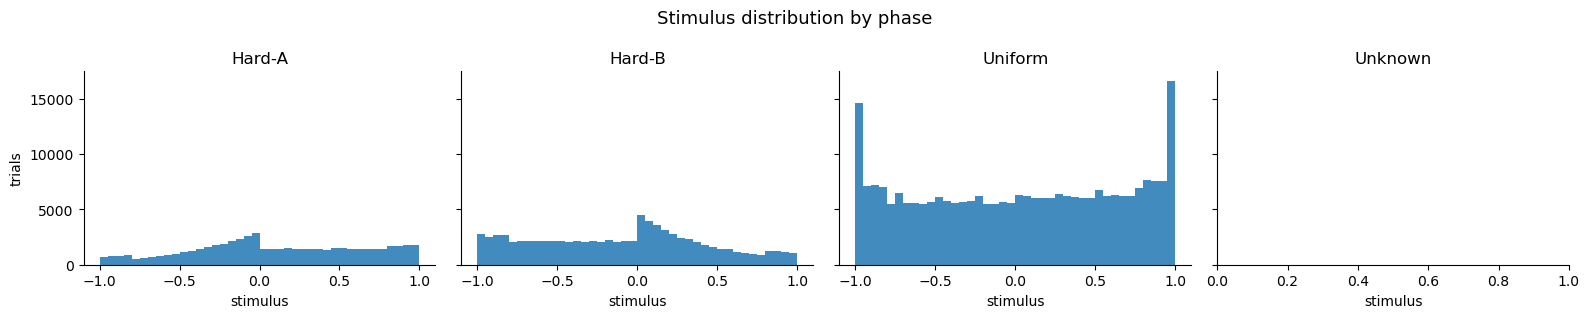

In [19]:
# distribution labels discovered from the data, not assumed
dists = sorted(all_table['distribution'].dropna().unique())
print('distribution labels present:', dists)

fig, axes = plt.subplots(1, len(dists), figsize=(4 * len(dists), 3.2), squeeze=False, sharey=True)
for ax, D in zip(axes[0], dists):
    stims = [pool_arrays(select_sessions(a, distribution=D))['stimuli']
             for a in experiment.animals.values() if select_sessions(a, distribution=D)]
    if stims:
        ax.hist(np.concatenate(stims), bins=40, color=get_colour(0), alpha=0.85)
    ax.set_title(D); ax.set_xlabel('stimulus')
axes[0][0].set_ylabel('trials')
fig.suptitle('Stimulus distribution by phase', fontsize=13); fig.tight_layout()

## §3 · Inventory

What data exists. The **availability matrix** is load-bearing: it shows which
animals have which session types, so the opto notebooks' assumption that every
opto animal also has masking can be checked here rather than discovered mid-analysis.

In [20]:
# genotype membership + session-type availability (does each animal have opto AND masking?)
for g, ids in groups.items():
    print(f"{g} (n={len(ids)}): {sorted(ids)}")
missing_g = sorted(set(all_table['animal']) - set(sum(groups.values(), [])))
if missing_g: print(f"unknown genotype: {missing_g}")

avail = (all_table.groupby(['animal', 'session_type']).size()
         .unstack('session_type', fill_value=0) > 0)
avail.insert(0, 'genotype', avail.index.map(by_animal).fillna('unknown'))
avail

het (n=17): ['SS01', 'SS02', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS13', 'SS15', 'SS16', 'SS19', 'SS21', 'SS22', 'SS23']
unknown (n=1): ['SS12']
wt (n=4): ['SS14', 'SS17', 'SS18', 'SS20']


session_type,genotype,alm_control_bi,alm_control_uni,masking,opto,regular,washout
animal,,,,,,,
SS01,het,False,False,False,False,True,False
SS02,het,False,False,False,False,True,False
SS04,het,False,False,False,False,True,False
SS05,het,False,False,False,False,True,False
SS06,het,False,False,False,False,True,False
SS07,het,False,False,False,False,True,False
SS08,het,False,False,False,False,True,False
SS09,het,False,False,False,False,True,False
SS10,het,False,False,False,False,True,False


In [21]:
# full composition: sessions per animal x distribution x session_type
comp = (all_table.groupby(['animal', 'distribution', 'session_type']).size()
        .unstack('session_type', fill_value=0))
comp

session_type         alm_control_bi  alm_control_uni  masking  opto  regular  \
animal distribution                                                            
SS01   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       46   
SS02   Uniform                    0                0        0     0       20   
SS04   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       63   
       Unknown                    0                0        0     0        2   
SS05   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       38   
SS06   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       37   
SS07   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       38   
SS08   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       18   
       Uniform                    0                0        0     0       42   
SS09   Hard-A                     0                0        0     0       12   
       Hard-B                     0                0        0     0       22   
       Uniform                    0                0        0     0       29   
SS10   Uniform                    0                0        0     0       63   
SS11   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       19   
       Uniform                    0                0        0     0       31   
SS12   Uniform                    0                0        0     0       16   
SS13   Hard-A                     0                0        0     0       13   
       Hard-B                     0                0        0     0       19   
       Uniform                    0                0        0     0       32   
SS14   Hard-A                     0                0        3     3        0   
       Hard-B                     0                0        3     3        0   
       Uniform                    5                4        2     5       22   
SS15   Hard-A                     0                0        3     3        0   
       Hard-B                     0                0        3     3        0   
       Uniform                    5                4        3     4       21   
SS16   Hard-A                     0                0        3     3        0   
       Hard-B                     0                0        3     3        0   
       Uniform                    5                4        4     5       20   
SS17   Uniform                    5                4        4     6       30   
SS18   Hard-A                     0                0        3     3        0   
       Hard-B                     0                0        3     3        0   
       Uniform                    5                4        2     5       21   
SS19   Uniform                    0                0        0     0       33   
SS20   Hard-A                     0                0        2     3        0   
       Hard-B                     0                0        4     3        0   
       Uniform                    5                4        0     5       21   


## §4 · Integrity & QC

Reports, doesn't assume. Anything flagged here is a session/animal a downstream
notebook should know about.

In [22]:
# per-animal totals + abort rate; MIN_SESSIONS gate flagged
qc = all_table.groupby('animal').agg(
    genotype=('genotype', 'first'),
    n_sessions=('session_id', 'nunique'),
    n_trials=('n_trials', 'sum'),
    n_valid=('n_valid', 'sum'),
)
qc['abort_rate'] = (1 - qc['n_valid'] / qc['n_trials']).round(3)
qc['below_min'] = qc['n_sessions'] < MIN_SESSIONS
qc

,genotype,n_sessions,n_trials,n_valid,abort_rate,below_min
animal,,,,,,
SS01,het,81,39039,37077,0.050,False
SS02,het,20,7897,6501,0.177,False
SS04,het,100,44632,40110,0.101,False
SS05,het,73,26611,24478,0.080,False
SS06,het,72,27013,24026,0.111,False
SS07,het,73,26528,23559,0.112,False
SS08,het,73,30017,28034,0.066,False
SS09,het,63,22267,19107,0.142,False
SS10,het,63,17335,14345,0.172,False


In [23]:
# flags: labels present, low-trial sessions
print('distribution labels:', sorted(all_table['distribution'].dropna().unique()))
print('session_type labels:', sorted(all_table['session_type'].dropna().unique()))
print('stage labels:', sorted(all_table['stage'].dropna().unique()))

TRIAL_FLOOR = 50
low = all_table[all_table['n_trials'] < TRIAL_FLOOR][
    ['animal', 'session_id', 'stage', 'distribution', 'session_type', 'n_trials']]
print(f"\nsessions below {TRIAL_FLOOR} trials: {len(low)}")
if len(low): print(low.to_string(index=False))

below = qc.index[qc['below_min']].tolist()
print(f"\nanimals below MIN_SESSIONS ({MIN_SESSIONS}): {below or 'none'}")

distribution labels: ['Hard-A', 'Hard-B', 'Uniform', 'Unknown']
session_type labels: ['alm_control_bi', 'alm_control_uni', 'masking', 'opto', 'regular', 'washout']
stage labels: ['', 'Full_Task_Cont', 'Full_Task_Disc', 'Habituation', 'Lick_To_Release', 'Three_And_Three']

sessions below 50 trials: 5
animal                session_id           stage distribution session_type  n_trials
  SS04 SOUND_CAT_SS04_2025_11_15                      Unknown      regular         0
  SS04 SOUND_CAT_SS04_2025_11_19 Three_And_Three      Uniform      regular        46
  SS04   SOUND_CAT_SS04_2026_1_8                      Unknown      regular         0
  SS04  SOUND_CAT_SS04_2026_1_13  Full_Task_Cont      Uniform      regular        34
  SS09   SOUND_CAT_SS09_2026_2_2 Three_And_Three      Uniform      regular        46

animals below MIN_SESSIONS (5): none


## §5 · Task sanity

Per animal, the psychometric for each analysis phase: every session's curve
(faint) plus the overall curve (bold). **All trials, including opto — no
filtering.** Phases (named presets):

- **uniform expert** — last 5 of `expert_uniform` (late, accuracy ≥ 0.70)
- **uniform masking / opto**, **hard-a masking / opto**, **hard-b masking / opto**

One glance per animal shows whether it is doing the task, session-to-session
consistency, and how the manipulation phases compare. Panels an animal lacks are
skipped; a chance-level session still shows — that is the point.

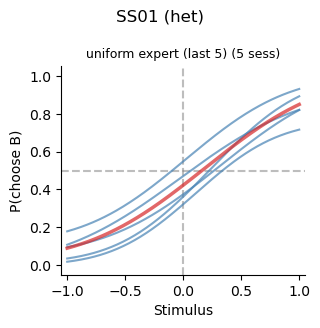

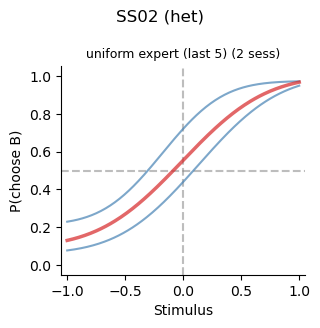

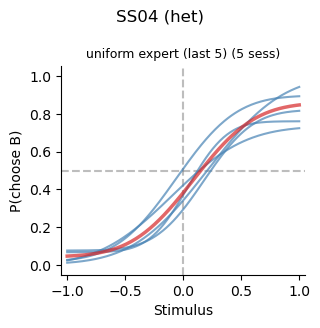

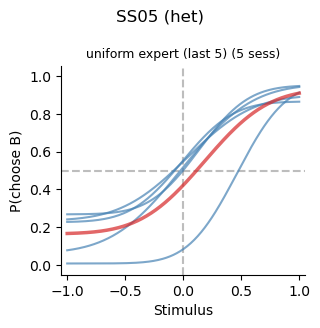

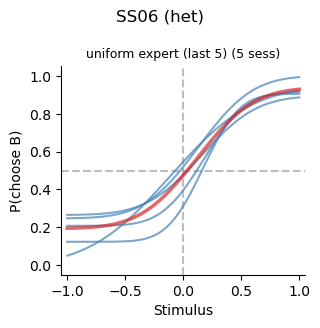

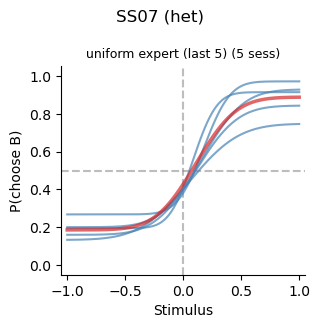

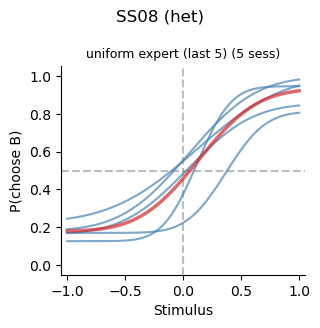

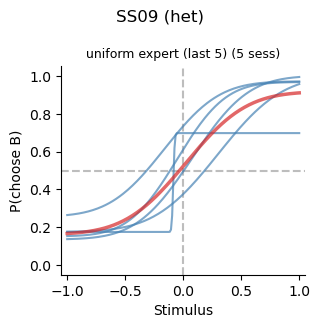

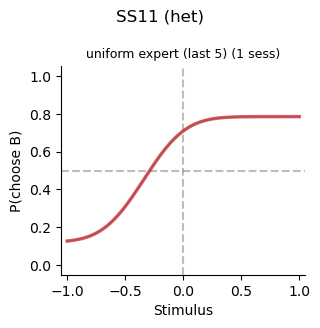

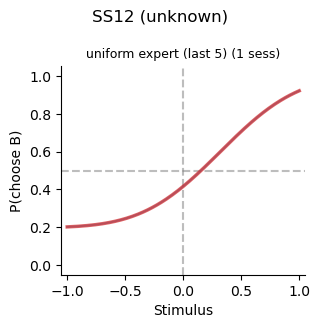

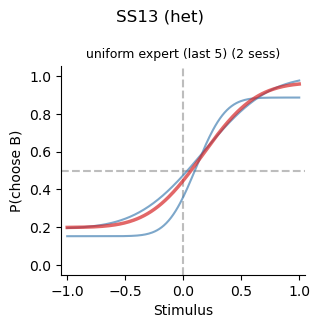

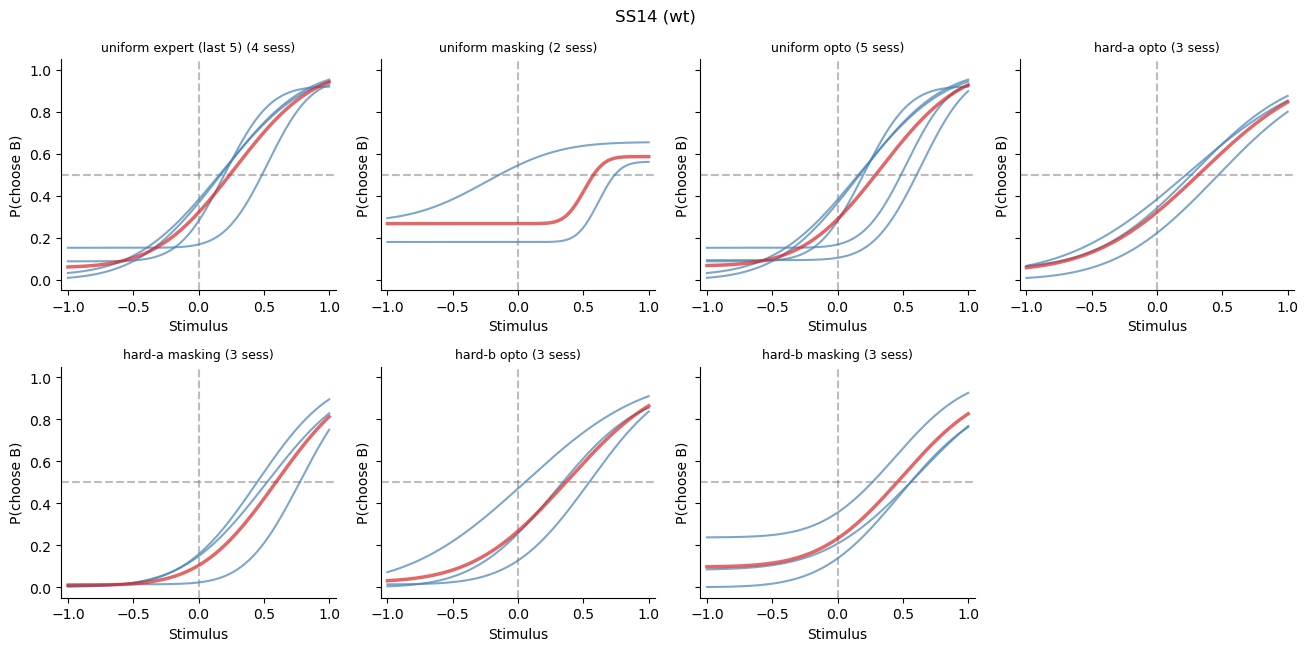

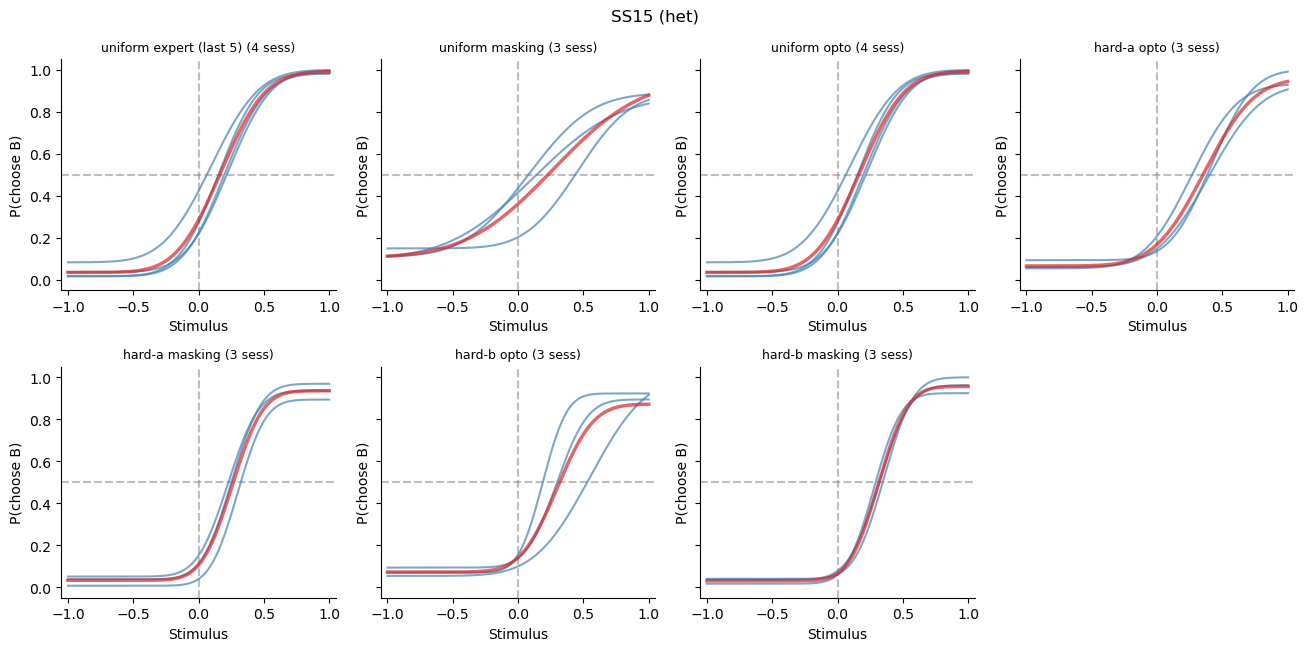

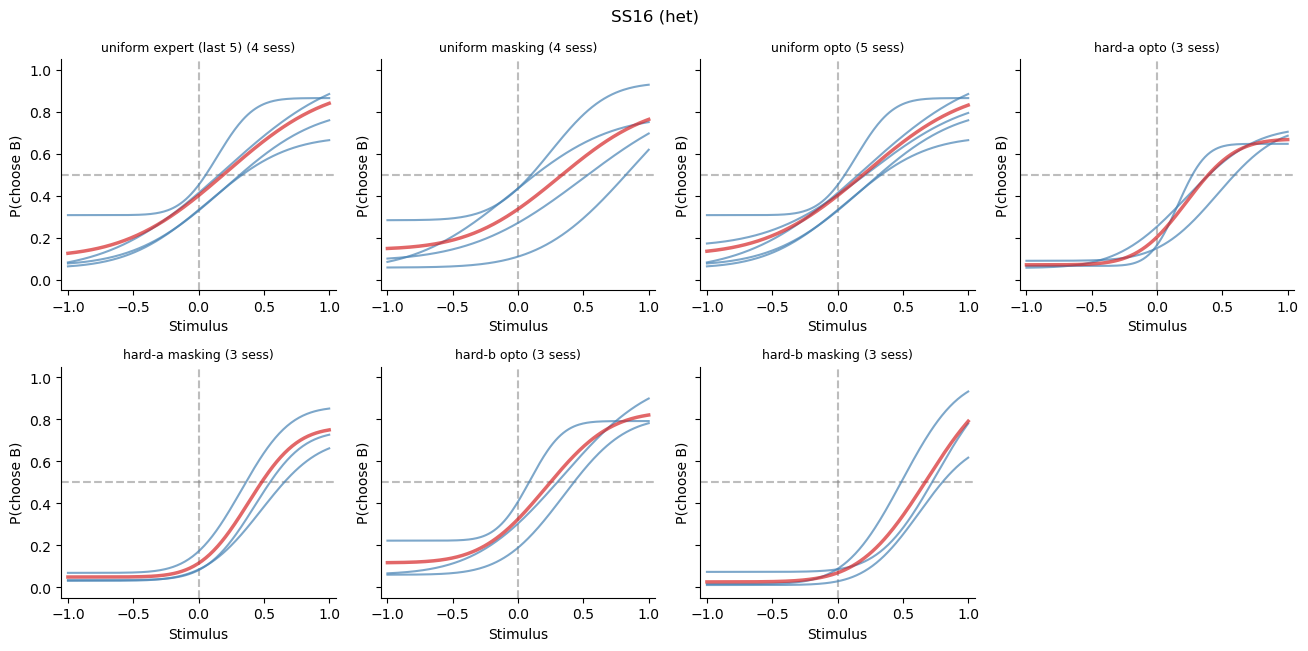

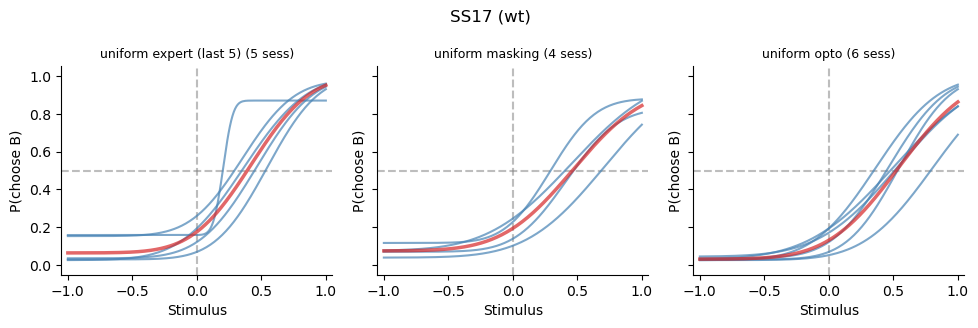

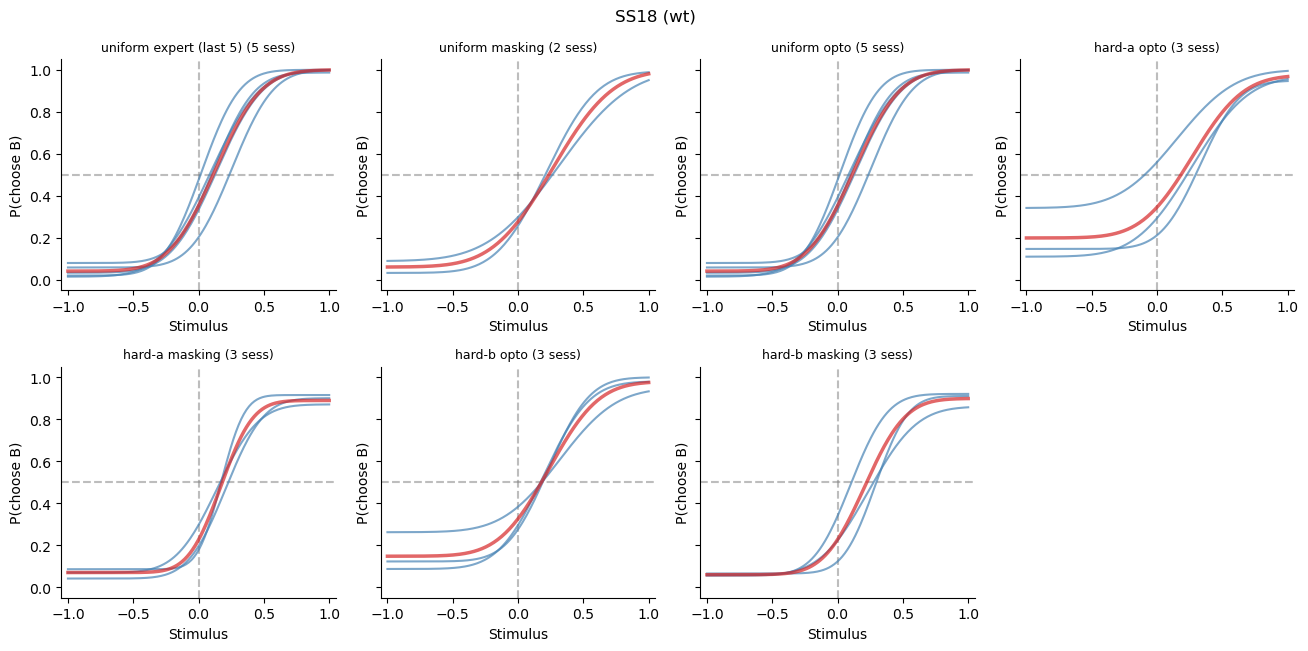

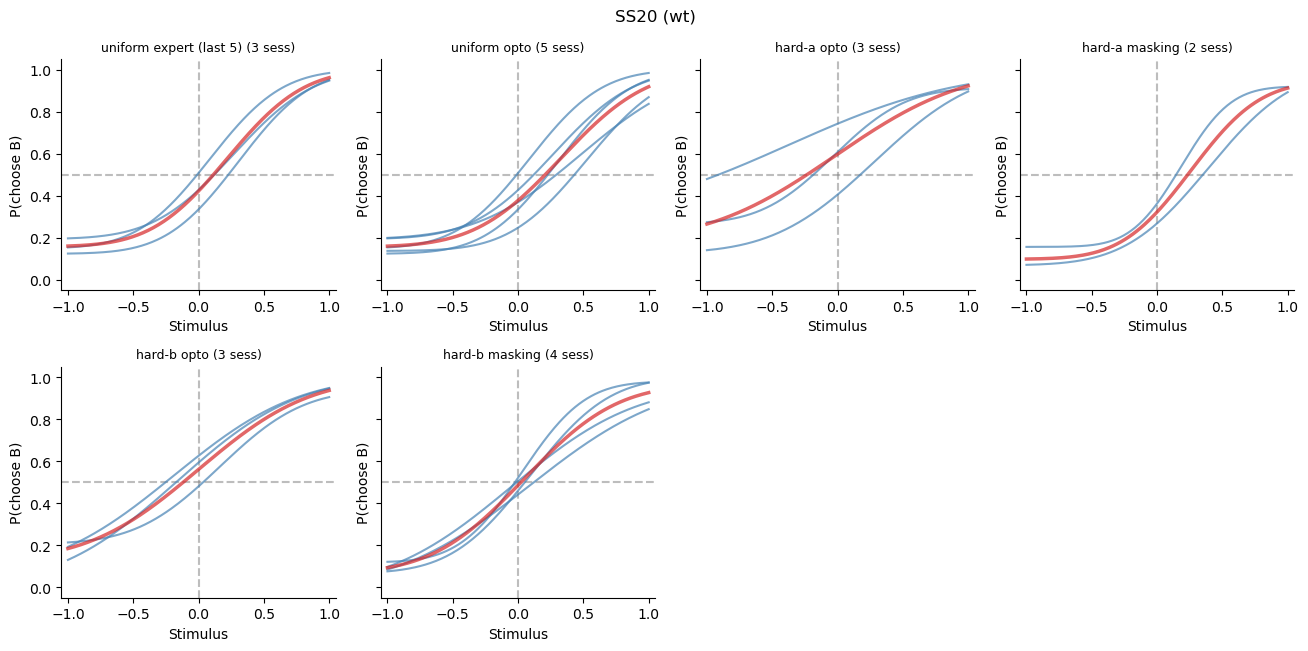

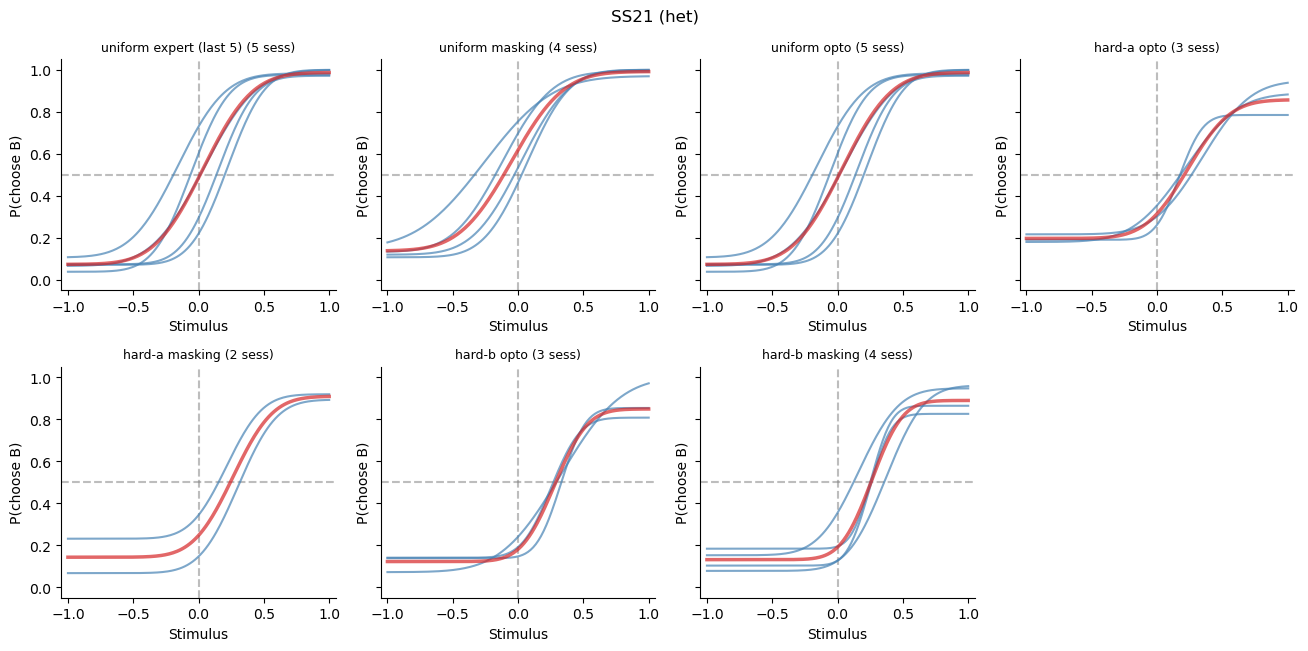

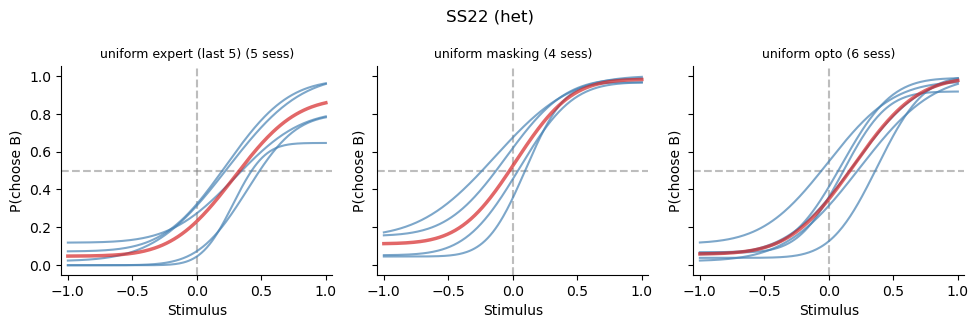

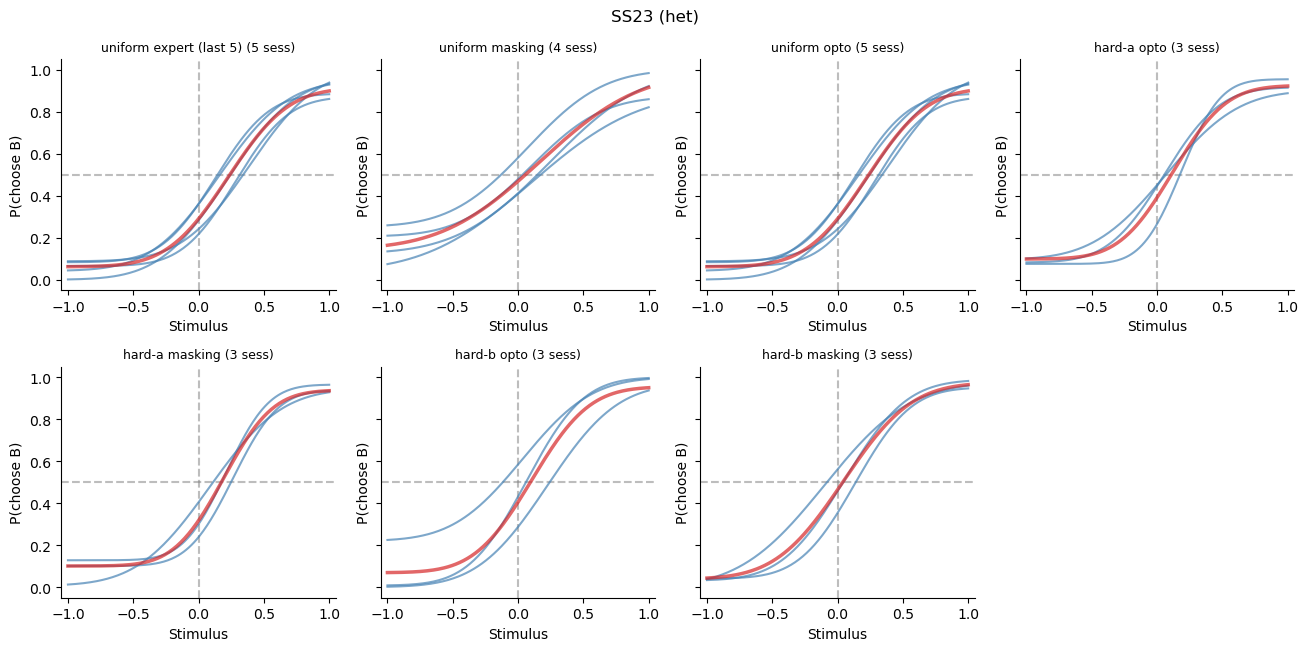

In [24]:
# task QC on the analysis phases (default presets); all trials incl opto, no filtering
QC_PHASES = [
    ('uniform expert (last 5)', 'expert_uniform',  5),
    ('uniform masking',         'uniform_masking', None),
    ('uniform opto',            'uniform_opto',    None),
    ('hard-a opto',             'hard_a_opto',     None),
    ('hard-a masking',          'hard_a_masking',  None),
    ('hard-b opto',             'hard_b_opto',     None),
    ('hard-b masking',          'hard_b_masking',  None),
]

for aid, a in experiment.animals.items():
    panels = []
    for label, preset, tail in QC_PHASES:
        ph = select_sessions(a, preset)
        if tail and ph:
            ph = sorted(ph, key=lambda s: s.session_idx)[-tail:]
        if ph:
            panels.append((label, ph))
    if not panels:
        continue
    ncols = min(4, len(panels)); nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows),
                             squeeze=False, sharey=True)
    axf = axes.ravel()
    for ax, (label, ph) in zip(axf, panels):
        plot_psychometric(compute_psychometric(ph, mode='per_session', n_bootstrap=0),
                          ax=ax, show_individual=True, show_data=False)
        plot_psychometric(compute_psychometric(ph, mode='pooled', n_bootstrap=0),
                          ax=ax, color=get_colour(3), linewidth=2.5, show_ci=False, show_data=False)
        ax.set_title(f"{label} ({len(ph)} sess)", fontsize=9)
    for ax in axf[len(panels):]: fig.delaxes(ax)
    fig.suptitle(f"{aid} ({by_animal.get(aid, 'unknown')})", fontsize=12); fig.tight_layout()

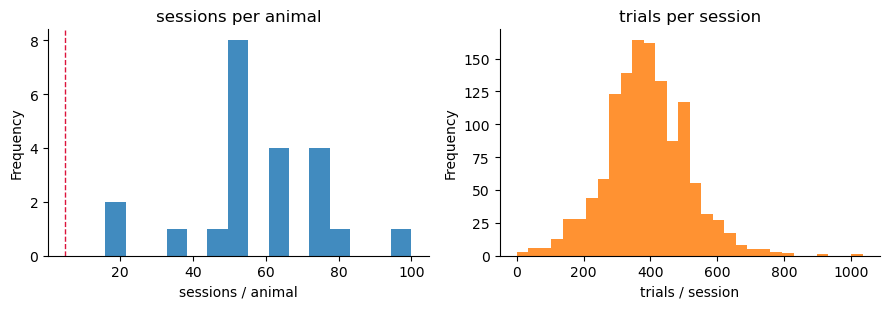

In [25]:
# trials/session and sessions/animal distributions
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
qc['n_sessions'].plot.hist(ax=axes[0], bins=15, color=get_colour(0), alpha=0.85)
axes[0].axvline(MIN_SESSIONS, color='crimson', ls='--', lw=1)
axes[0].set_xlabel('sessions / animal'); axes[0].set_title('sessions per animal')
all_table['n_trials'].plot.hist(ax=axes[1], bins=30, color=get_colour(1), alpha=0.85)
axes[1].set_xlabel('trials / session'); axes[1].set_title('trials per session')
fig.tight_layout()

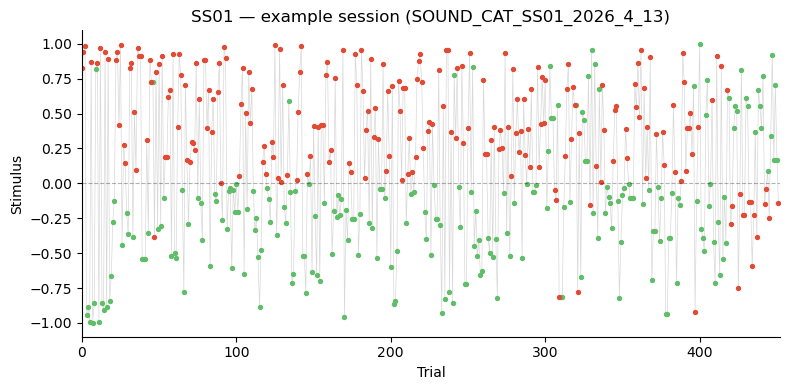

In [26]:
# one example session raster
aid0 = opto_ids[0] if opto_ids else list(experiment.animals)[0]
ph0 = select_sessions(experiment.get_animal(aid0), distribution=dists[0])
if ph0:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_session_raster(compute_session_raster(ph0[0]), ax=ax)
    ax.set_title(f"{aid0} — example session ({ph0[0].session_id})")
    fig.tight_layout()
else:
    print('no task-stage sessions to raster')

## §6 · Summary

Headline below. Read-only — nothing written; the inventory lives in the tables
above. Every downstream notebook can assume this cohort, these labels, and these
flags.

In [27]:
print(f"Animals:  {experiment.n_animals}  (" + ', '.join(f'{g}={len(ids)}' for g, ids in groups.items()) + ')')
print(f"Sessions: {int(qc['n_sessions'].sum())}    Trials: {int(qc['n_trials'].sum()):,}")
print(f"Phases:   {dists}")
print(f"Sess types: {sorted(all_table['session_type'].dropna().unique())}")
print(f"Dates:    {all_table['date'].min()} – {all_table['date'].max()}")

Animals:  22  (het=17, unknown=1, wt=4)
Sessions: 1267    Trials: 492,297
Phases:   ['Hard-A', 'Hard-B', 'Uniform', 'Unknown']
Sess types: ['alm_control_bi', 'alm_control_uni', 'masking', 'opto', 'regular', 'washout']
Dates:    2025-11-15 – 2026-07-18
